In [ ]:
"""
    File: modello.ipynb
    Author: Andrea Macale
    Date: 2026-03-04

    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici

"""

'\n    File: modello.ipynb\n    Author: Andrea Macale\n    Date: 2026-03-04\n\n    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici\n\n'

# Parte 0: Importazione delle librerie

In [2]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


## Librerie principali

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

In [ ]:
import sys

# Si sposta nella directory principale dello Studio
os.chdir('/teamspace/studios/this_studio')

# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /teamspace/studios/this_studio


## Correlazione 

In [47]:
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import spearmanr

## VIF

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

## Distribuzione dei dati

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Train

In [ ]:
import torch
import torchvision.transforms as T
import torch.nn as nn
from src.train.train import train_modello_visivo, train_modello_clinico
from src.models.DiagnosiIntegrata import DiagnosiIntegrata
from src.features.RXToraceDataset import RXToraceDataset
from tqdm.auto import tqdm

## Path

# Parte 1: Estrazione dei dati

## Aperta dei file del dataset

In [52]:
pos_dataset = os.path.join("data")

In [53]:
file = os.path.join(pos_dataset, "patients.csv")
pazienti = pd.read_csv(file)
pazienti['subject_id'] = pazienti['subject_id'].astype(str)
pazienti.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [54]:
file = os.path.join(pos_dataset, "diagnoses_icd.csv")
tipi = {
    'subject_id': str, 
    'hadm_id': str, 
    'icd_code': str, 
    'icd_version': str
}
diagnosi = pd.read_csv(file, dtype=tipi)
diagnosi['icd_version'] = pd.to_numeric(diagnosi['icd_version'], errors='coerce').fillna(0).astype(int)
diagnosi = diagnosi.drop_duplicates()
diagnosi.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [55]:
file = os.path.join(pos_dataset, "mimic-cxr-2.0.0-metadata.csv")
metadati = pd.read_csv(file)
metadati['dicom_id'] = metadati['dicom_id'].astype(str)
metadati['subject_id'] = metadati['subject_id'].astype(str)
metadati['study_id'] = metadati['study_id'].astype(str)
metadati.head()

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN


In [56]:
lista_immagini = []
ricerca = Path(os.path.join(pos_dataset, "MIMIC_SUPER_RES_24K"))
for file_path in ricerca.rglob('*.jpg'):
    dicom_id = file_path.stem
    lista_immagini.append({'dicom_id': dicom_id, 'path_immagine': str(file_path)})
immagini = pd.DataFrame(lista_immagini)
immagini['path_immagine'] = immagini['path_immagine'].str.replace(str(pos_dataset+"/"), "data/", regex=False) # pulisci il path
immagini['dicom_id'] = immagini['dicom_id'].astype(str)
print(f"{len(immagini)} immagini")
immagini.head()

24000 immagini


,dicom_id,path_immagine
0,a1caa841-da9f9653-8bd9d123-4c075f29-fd765493,data/MIMIC_SUPER_RES_24K/a1caa841-da9f9653-8bd...
1,8436c8e1-fd1bebcd-ae0f714e-75eb2e0f-7f6fa026,data/MIMIC_SUPER_RES_24K/8436c8e1-fd1bebcd-ae0...
2,a20b1ca6-a7d072b9-528d1661-d9c06217-2157f230,data/MIMIC_SUPER_RES_24K/a20b1ca6-a7d072b9-528...
3,5edacc39-6245cb11-d691387f-7f1dfdf7-87212f5f,data/MIMIC_SUPER_RES_24K/5edacc39-6245cb11-d69...
4,c7727ad3-2f536e7d-2ae4cb75-f60291ec-c561e51e,data/MIMIC_SUPER_RES_24K/c7727ad3-2f536e7d-2ae...


In [57]:
def leggi_singolo_referto(file_path):
    """Funzione helper per la lettura parallela"""
    study_id = file_path.stem.replace("s", "")
    with open(file_path, 'r', encoding='utf-8') as f:
        testo = f.read()
    return {'study_id': str(study_id), 'testo_referto': testo}

lista_referti = []
ricerca_referti = Path(os.path.join(pos_dataset, "mimic-cxr-reports"))
files = list(ricerca_referti.rglob('*.txt'))

print(f"Inizio caricamento di {len(files)} file...")

# Usa ThreadPoolExecutor per saturare il Disk I/O
# Su Lightning AI T4 puoi usare tranquillamente 8 o 16 worker
with ThreadPoolExecutor(max_workers=8) as executor:
    lista_referti = list(tqdm(executor.map(leggi_singolo_referto, files), total=len(files)))

referti = pd.DataFrame(lista_referti)
print(f"Caricati {len(referti)} referti.")

Inizio caricamento di 227835 file...


  0%|          | 0/227835 [00:00<?, ?it/s]

Caricati 227835 referti.


## Prima pulizia, selezione e join dei dati

In [58]:
dataset = pazienti.merge(metadati, on=['subject_id'], how='inner')
dataset = dataset.merge(immagini, on=['dicom_id'], how='inner')
dataset = dataset.merge(referti, on=['study_id'], how='inner')
print(len(dataset))
dataset

22768


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,path_immagine,testo_referto
0,10000898,F,80,2188,2014 - 2016,NaN,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,CHEST (PA AND LAT),PA,2544,3056,21880312,125501.842,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...
1,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,2022,1736,21860730,155005.000,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...
2,10001401,F,89,2131,2014 - 2016,NaN,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,PORTABLE ABDOMEN,AP,3056,2544,21310610,102234.484,DX CHEST PORT LINE/TUBE PLCMT 1 EXAM,antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...
3,10001401,F,89,2131,2014 - 2016,NaN,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,CHEST (PA AND LAT),PA,3056,2544,21310619,193047.156,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...
4,10001401,F,89,2131,2014 - 2016,NaN,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,Performed Desc,PA,2021,2021,21310802,114559.000,CHEST (PA AND LAT),postero-anterior,Recumbent,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22763,19998330,F,71,2177,2011 - 2013,2178-12-08,05405a03-c11efc6e-8a4366b6-d929640f-c356d564,59735820,CHEST (PORTABLE AP),AP,2453,2306,21781021,170349.875,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/05405a03-c11efc6e-8a4...,FINAL REPORT\...
22764,19998350,M,52,2127,2011 - 2013,NaN,d14b91a7-2deb65ba-dea8e4b9-b7bbeb5e-f3ac734f,51819111,CHEST (PA AND LAT),PA,3056,2544,21280221,85427.984,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/d14b91a7-2deb65ba-dea...,FINAL REPORT\...
22765,19999287,F,71,2191,2008 - 2010,2197-09-02,50373d1b-8df0d15f-5d0047f4-578bc509-4f2b48f0,51885769,CHEST (PORTABLE AP),AP,3056,2544,21970726,25712.640,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/50373d1b-8df0d15f-5d0...,FINAL REPORT\...
22766,19999287,F,71,2191,2008 - 2010,2197-09-02,46510b80-411ac511-fe6ffab2-d7dfdc76-dff1a762,52519175,CHEST (PORTABLE AP),AP,2544,3056,21970807,90637.796,CHEST (PORTABLE AP),antero-posterior,NaN,data/MIMIC_SUPER_RES_24K/46510b80-411ac511-fe6...,FINAL REPORT\...


In [59]:
condizioni = [
    # STADIO IV: Metastasi (Il più grave)
    diagnosi['icd_code'].str.startswith(('196', '197', '198', '199', 'C77', 'C78', 'C79'), na=False),
    
    # STADIO I-III: Tumore Primario Invasivo
    diagnosi['icd_code'].str.startswith(('162', 'C34'), na=False),
    
    # BENIGNO: Tumori non maligni (ICD-9: 212.3 | ICD-10: D14.3)
    diagnosi['icd_code'].str.startswith(('2123', 'D143'), na=False),
    
    # A RISCHIO: Noduli o ombre (Sospetti non confermati)
    diagnosi['icd_code'].str.contains('793.1|R91', na=False)
]
valori = [4, 3, 2, 1]
diagnosi['numero_severita'] = np.select(condizioni, valori, default=0)
etichette_pazienti = diagnosi.groupby('subject_id')['numero_severita'].max().reset_index()
mappa_severita = {
    4: 'IV STADIO: METASTATICO',
    3: 'I-III STADIO: PRIMARIO',
    2: 'BENIGNO',
    1: 'A RISCHIO',
    0: 'NEGATIVO'
}
etichette_pazienti['stato_clinico'] = etichette_pazienti['numero_severita'].map(mappa_severita)

In [60]:
dataset = dataset.merge(etichette_pazienti, on=['subject_id'], how='left')
dataset['numero_severita'] = pd.to_numeric(dataset['numero_severita'], errors='coerce')
dataset['numero_severita'] = dataset['numero_severita'].fillna(0)
dataset['numero_severita'] = dataset['numero_severita'].astype('int64')
dataset['stato_clinico'] = dataset['stato_clinico'].fillna('NEGATIVO')
dataset

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,dicom_id,study_id,PerformedProcedureStepDescription,ViewPosition,...,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,path_immagine,testo_referto,numero_severita,stato_clinico
0,10000898,F,80,2188,2014 - 2016,NaN,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,CHEST (PA AND LAT),PA,...,3056,21880312,125501.842,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...,0,NEGATIVO
1,10000935,F,52,2182,2008 - 2010,2187-11-12,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,NaN,PA,...,1736,21860730,155005.000,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...,4,IV STADIO: METASTATICO
2,10001401,F,89,2131,2014 - 2016,NaN,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,PORTABLE ABDOMEN,AP,...,2544,21310610,102234.484,DX CHEST PORT LINE/TUBE PLCMT 1 EXAM,antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,1,A RISCHIO
3,10001401,F,89,2131,2014 - 2016,NaN,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,CHEST (PA AND LAT),PA,...,2544,21310619,193047.156,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,1,A RISCHIO
4,10001401,F,89,2131,2014 - 2016,NaN,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,Performed Desc,PA,...,2021,21310802,114559.000,CHEST (PA AND LAT),postero-anterior,Recumbent,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,1,A RISCHIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22763,19998330,F,71,2177,2011 - 2013,2178-12-08,05405a03-c11efc6e-8a4366b6-d929640f-c356d564,59735820,CHEST (PORTABLE AP),AP,...,2306,21781021,170349.875,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/05405a03-c11efc6e-8a4...,FINAL REPORT\...,0,NEGATIVO
22764,19998350,M,52,2127,2011 - 2013,NaN,d14b91a7-2deb65ba-dea8e4b9-b7bbeb5e-f3ac734f,51819111,CHEST (PA AND LAT),PA,...,2544,21280221,85427.984,CHEST (PA AND LAT),postero-anterior,Erect,data/MIMIC_SUPER_RES_24K/d14b91a7-2deb65ba-dea...,FINAL REPORT\...,0,NEGATIVO
22765,19999287,F,71,2191,2008 - 2010,2197-09-02,50373d1b-8df0d15f-5d0047f4-578bc509-4f2b48f0,51885769,CHEST (PORTABLE AP),AP,...,2544,21970726,25712.640,CHEST (PORTABLE AP),antero-posterior,Erect,data/MIMIC_SUPER_RES_24K/50373d1b-8df0d15f-5d0...,FINAL REPORT\...,3,I-III STADIO: PRIMARIO
22766,19999287,F,71,2191,2008 - 2010,2197-09-02,46510b80-411ac511-fe6ffab2-d7dfdc76-dff1a762,52519175,CHEST (PORTABLE AP),AP,...,3056,21970807,90637.796,CHEST (PORTABLE AP),antero-posterior,NaN,data/MIMIC_SUPER_RES_24K/46510b80-411ac511-fe6...,FINAL REPORT\...,3,I-III STADIO: PRIMARIO


# Parte 2: Gestione dei valori nulli e correlazione dei dati

In [61]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 22768 entries, 0 to 22767
Data columns (total 21 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   subject_id                                  22768 non-null  str    
 1   gender                                      22768 non-null  str    
 2   anchor_age                                  22768 non-null  int64  
 3   anchor_year                                 22768 non-null  int64  
 4   anchor_year_group                           22768 non-null  str    
 5   dod                                         9424 non-null   str    
 6   dicom_id                                    22768 non-null  str    
 7   study_id                                    22768 non-null  str    
 8   PerformedProcedureStepDescription           21128 non-null  str    
 9   ViewPosition                                22768 non-null  str    
 10  Rows                 

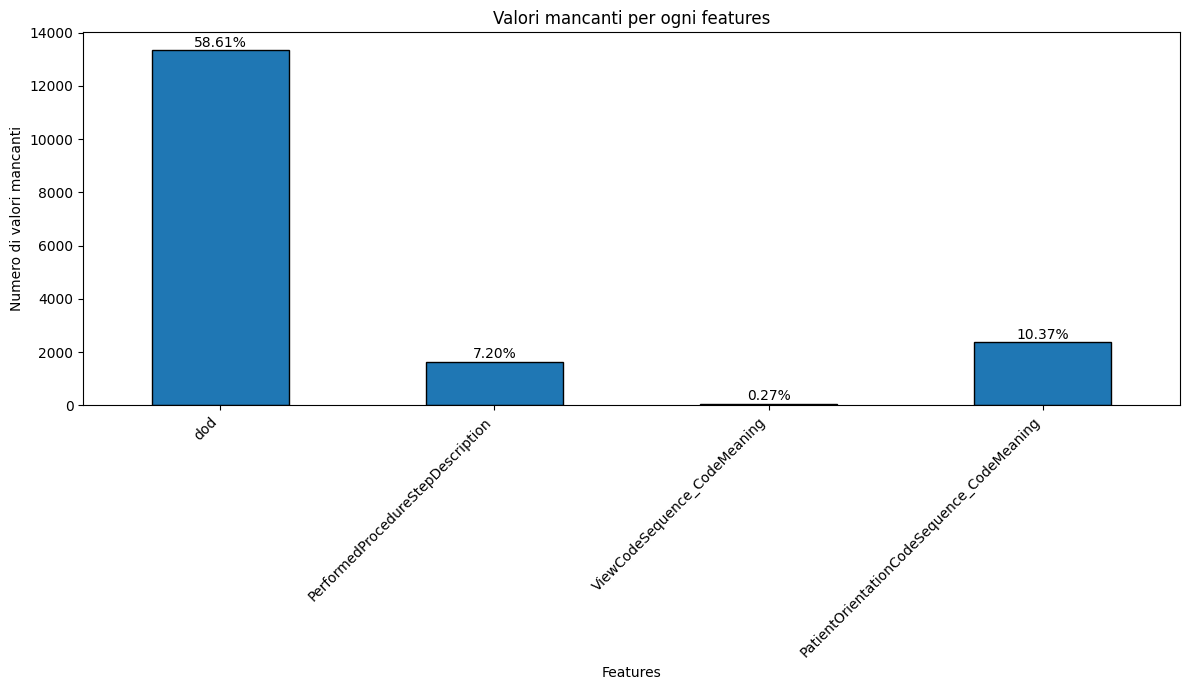

In [62]:
def plot_valori_mancanti(dataset):
    valori_nulli = dataset.isnull().sum()
    valori_nulli = valori_nulli[valori_nulli > 0]
    percentuale = valori_nulli / len(dataset) * 100
    plt.figure(figsize=(12, 7), dpi=100)
    valori_nulli.plot(kind='bar', edgecolor='black')
    for chiave, valore in enumerate(valori_nulli):
        plt.text(chiave, valore + (max(valori_nulli) * 0.01), f"{percentuale.iloc[chiave]:.2f}%", ha='center', fontsize=10)
    plt.title('Valori mancanti per ogni features')
    plt.ylabel('Numero di valori mancanti')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
        
plot_valori_mancanti(dataset)

I valori mancanti significativi sono i seguenti:
- dod (buona parte), che rappresenta la data di morte (sicuramente rumore);
- PatientOrientationCodeSequence_CodeMeaning, che è un dato molto tecnico e spesso ridondante;
- PerformedProcedureStepDescription, anch'esso ridondante dato che ci sono i reperti testuali;
- ViewCodeSequence_CodeMeaning, ennesima ripetizione verbosa.<br>
Per questo motivo le feature si possono eliminare tranquillamente.<br>
Inoltre altri dati superfli sono:
- Rows e Columns, perché avviene comunque la ridimensione del dataset;
- anchor_year_group ed anchor_year, poiché sono solamente dati amministrativi;
- ProcedureCodeSequence_CodeMeaning (un'altra ridondanza)

In [63]:
colonne_da_eliminare = [
    'dod',
    'PatientOrientationCodeSequence_CodeMeaning',
    'PerformedProcedureStepDescription',
    'ViewCodeSequence_CodeMeaning',
    'ProcedureCodeSequence_CodeMeaning',
    'Rows',
    'Columns',
    'anchor_year_group',
    'anchor_year'
]
dataset = dataset.drop(columns=colonne_da_eliminare, errors='ignore')
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'dicom_id', 'study_id', 'ViewPosition', 'StudyDate', 'StudyTime', 'path_immagine', 'testo_referto', 'numero_severita', 'stato_clinico']


## Normalizzazione dei dati

In [64]:
dataset.head()

,subject_id,gender,anchor_age,dicom_id,study_id,ViewPosition,StudyDate,StudyTime,path_immagine,testo_referto,numero_severita,stato_clinico
0,10000898,F,80,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,PA,21880312,125501.842,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...,0,NEGATIVO
1,10000935,F,52,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,PA,21860730,155005.000,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...,4,IV STADIO: METASTATICO
2,10001401,F,89,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,AP,21310610,102234.484,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,1,A RISCHIO
3,10001401,F,89,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,PA,21310619,193047.156,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,1,A RISCHIO
4,10001401,F,89,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,PA,21310802,114559.000,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,1,A RISCHIO


In [65]:
colonne_feature = ['gender', 'anchor_age', 'ViewPosition', 'StudyDate', 'StudyTime']
feature = dataset[colonne_feature].copy()
encoder = LabelEncoder()
feature['gender'] = encoder.fit_transform(feature['gender'])
feature['ViewPosition'] = encoder.fit_transform(feature['ViewPosition'])

## Matrice di correlazione e calcolo del VIF

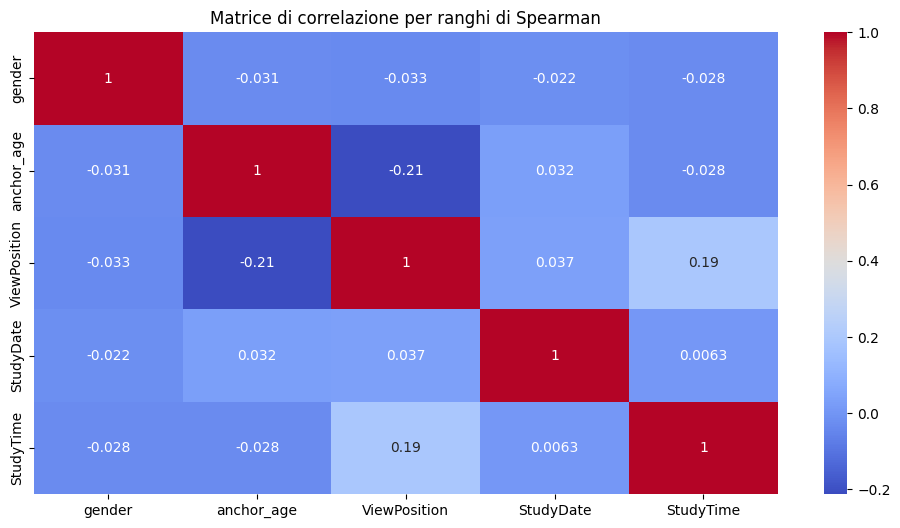

In [66]:
plt.figure(figsize=(12, 6))
plt.title('Matrice di correlazione per ranghi di Spearman')
sns.heatmap(feature.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

Come si può notare, non si hanno correlazioni dei dati significative. Quelle che sono leggermente più alte sono tra ViewPosition ed anchor_age e tra ViewPosition e StudyTime. Adesso, si calcolano il VIF, per verificare se è presente multicolinearità.

In [67]:
vif_data = pd.DataFrame()
vif_data['feature'] = colonne_feature
feature_const = sm.add_constant(feature)
vif_data['VIF'] = [variance_inflation_factor(feature_const.values, ind+1) for ind in range(feature.shape[1])]
print(vif_data)

        feature       VIF
0        gender  1.002925
1    anchor_age  1.052049
2  ViewPosition  1.092192
3     StudyDate  1.004138
4     StudyTime  1.039231


Come si può notare, ogni feature possiede colinearità debole, perciò è del tutto inutile eseguire procedure di riduzione di dimensionalità.

# Parte 3: Distribuzione dei dati

L'unico dato rilevante per calcolare gli outliers è l'anchor_age, poiché è l'unica variabile continua e può mostrare la demografia dei pazienti. I box-plot sugli altri dati non fornirebbe dati interessanti per il modello. Perciò, il box-plot viene fatto su anchor_age diviso per stadio_clinico, per vedere le fascie di età più colpite.

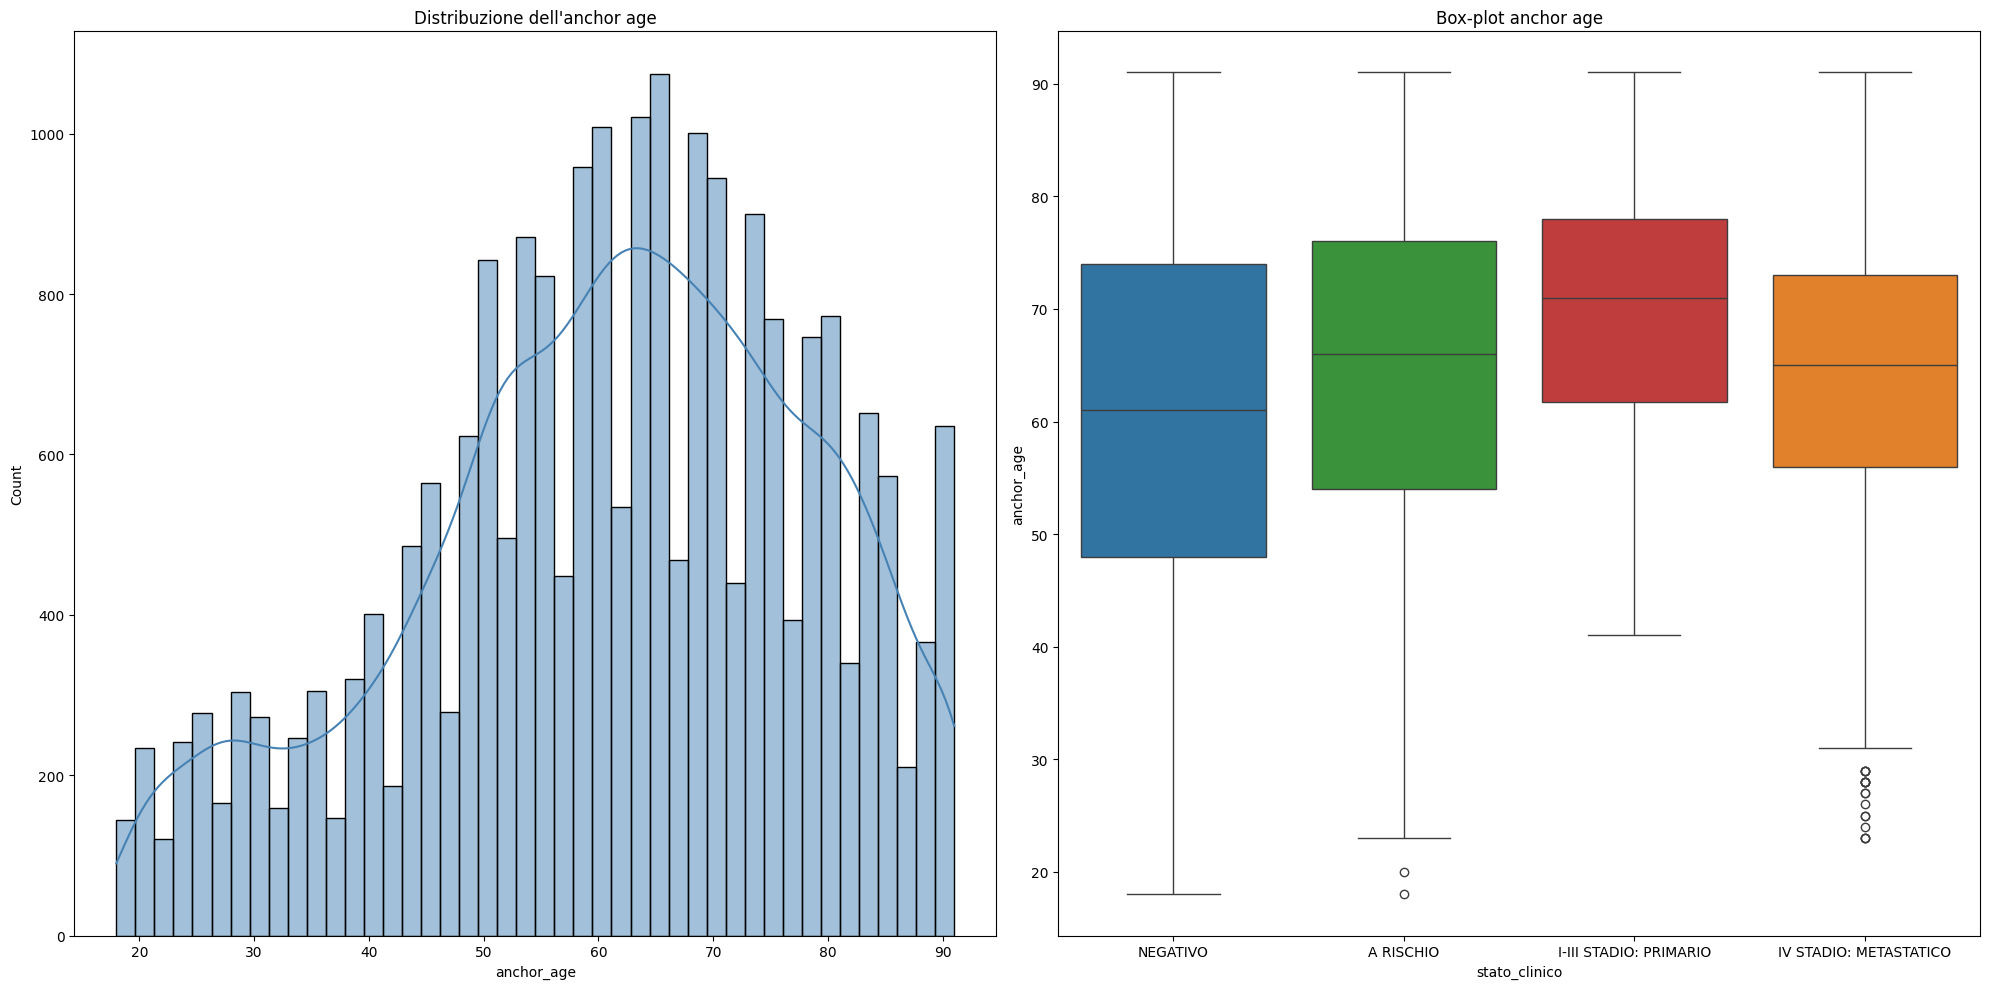

In [68]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
ordine_clinico = [
    'NEGATIVO', 
    'A RISCHIO',
    'I-III STADIO: PRIMARIO', 
    'IV STADIO: METASTATICO'
]
sns.histplot(dataset['anchor_age'], kde=True, ax=axis[0], color='steelblue')
sns.boxplot(x='stato_clinico', y='anchor_age', data=dataset, order=ordine_clinico ,ax=axis[1], hue='stato_clinico', legend=False)
axis[0].set_title("Distribuzione dell'anchor age")
axis[1].set_title("Box-plot anchor age")
plt.tight_layout()
plt.show()

Il grafico a sinistra mostra che la frequenza assoluta dell'età all'interno del dataset:
- concentrazione anagrafica: la distribuzione è asimmetrica, con una chiara pendenza verso le fasce d'età più alte;
- picco di incidenza: la moda del campione si colloca tra i 60 e i 65 anni, che è l'età media tipica in cui vengono prescritti esami radiologici per indagini polmonari e oncologiche;
- fasce giovani: è visibile una marcata coda a sinistra con un picco minore intorno ai 25-30 anni, che rappresenta i pazienti più giovani sottoposti a screening.

Il grafico a destra scompone l'età in base alle quattro categorie diagnostiche, permettendo di osservare le variazioni demografiche a seconda della severità della malattia:
- Negativo: essendo la classe maggioritaria di controllo, presenta una distribuzione estremamente ampia che copre l'intero range anagrafico (dai 18 ai 90 anni), con una mediana che si attesta intorno ai 61 anni;
- A Rischio: presenta una mediana più alta e una variabilità estesa;
- Stadio 0: non presenti nel dataset;
- I-III Stadio: questa classe registra la mediana più elevata del dataset, che conferma il fatto che statisticamente i tumori primari vengono diagnosticati prevalentemente nella popolazione geriatrica;
- IV Stadio: mostra molti outlier inferiori marcati, indicando un sottogruppo di pazienti eccezionalmente giovani (tra i 20 e i 30 anni) colpiti da malattia in stadio avanzato.

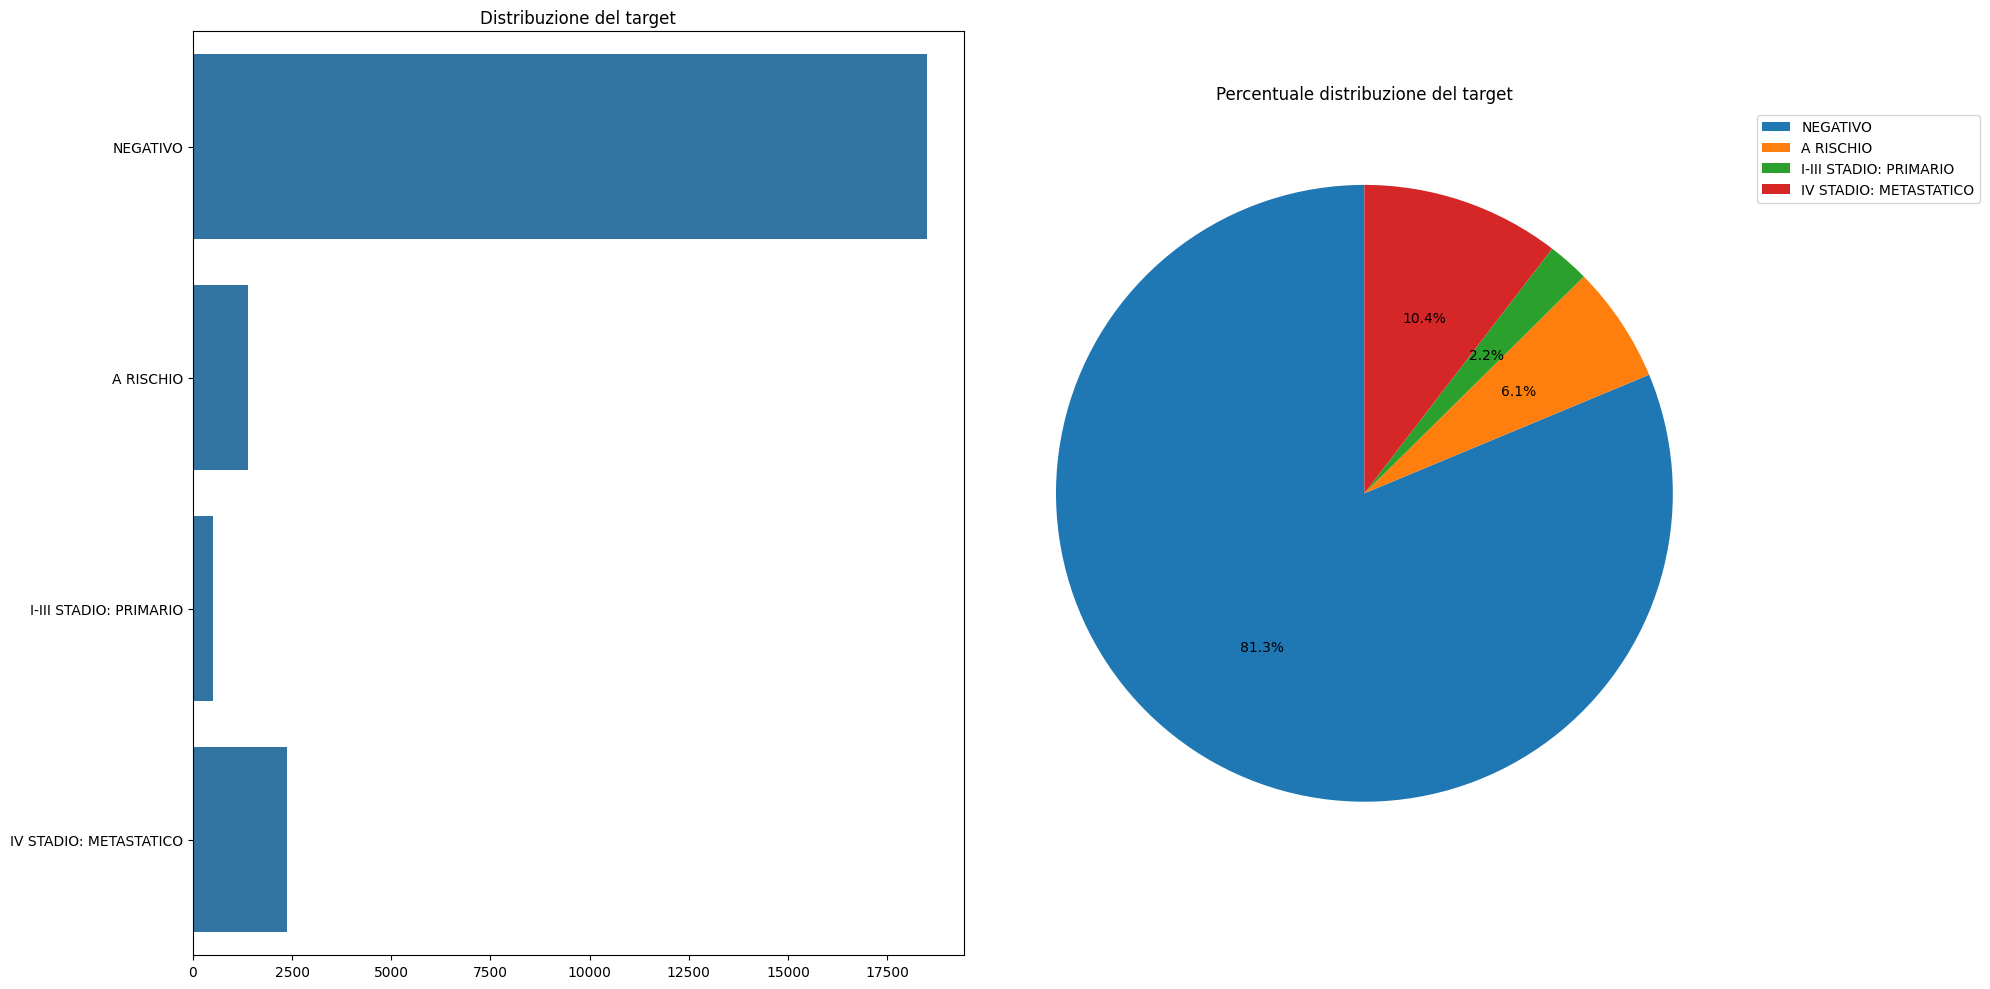

In [69]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
target_counts = dataset['stato_clinico'].value_counts().reindex(ordine_clinico)
sns.barplot(x=target_counts.values, y=ordine_clinico, ax=axis[0])
axis[1].pie(target_counts.values, labels=None, autopct='%1.1f%%', startangle=90)
axis[0].set_title("Distribuzione del target")
axis[1].set_title("Percentuale distribuzione del target")
axis[1].legend(labels=ordine_clinico, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Come si può notare, il dataset è molto sbilanciato di casi negativi. Per il momento, escludiamo i negativi.

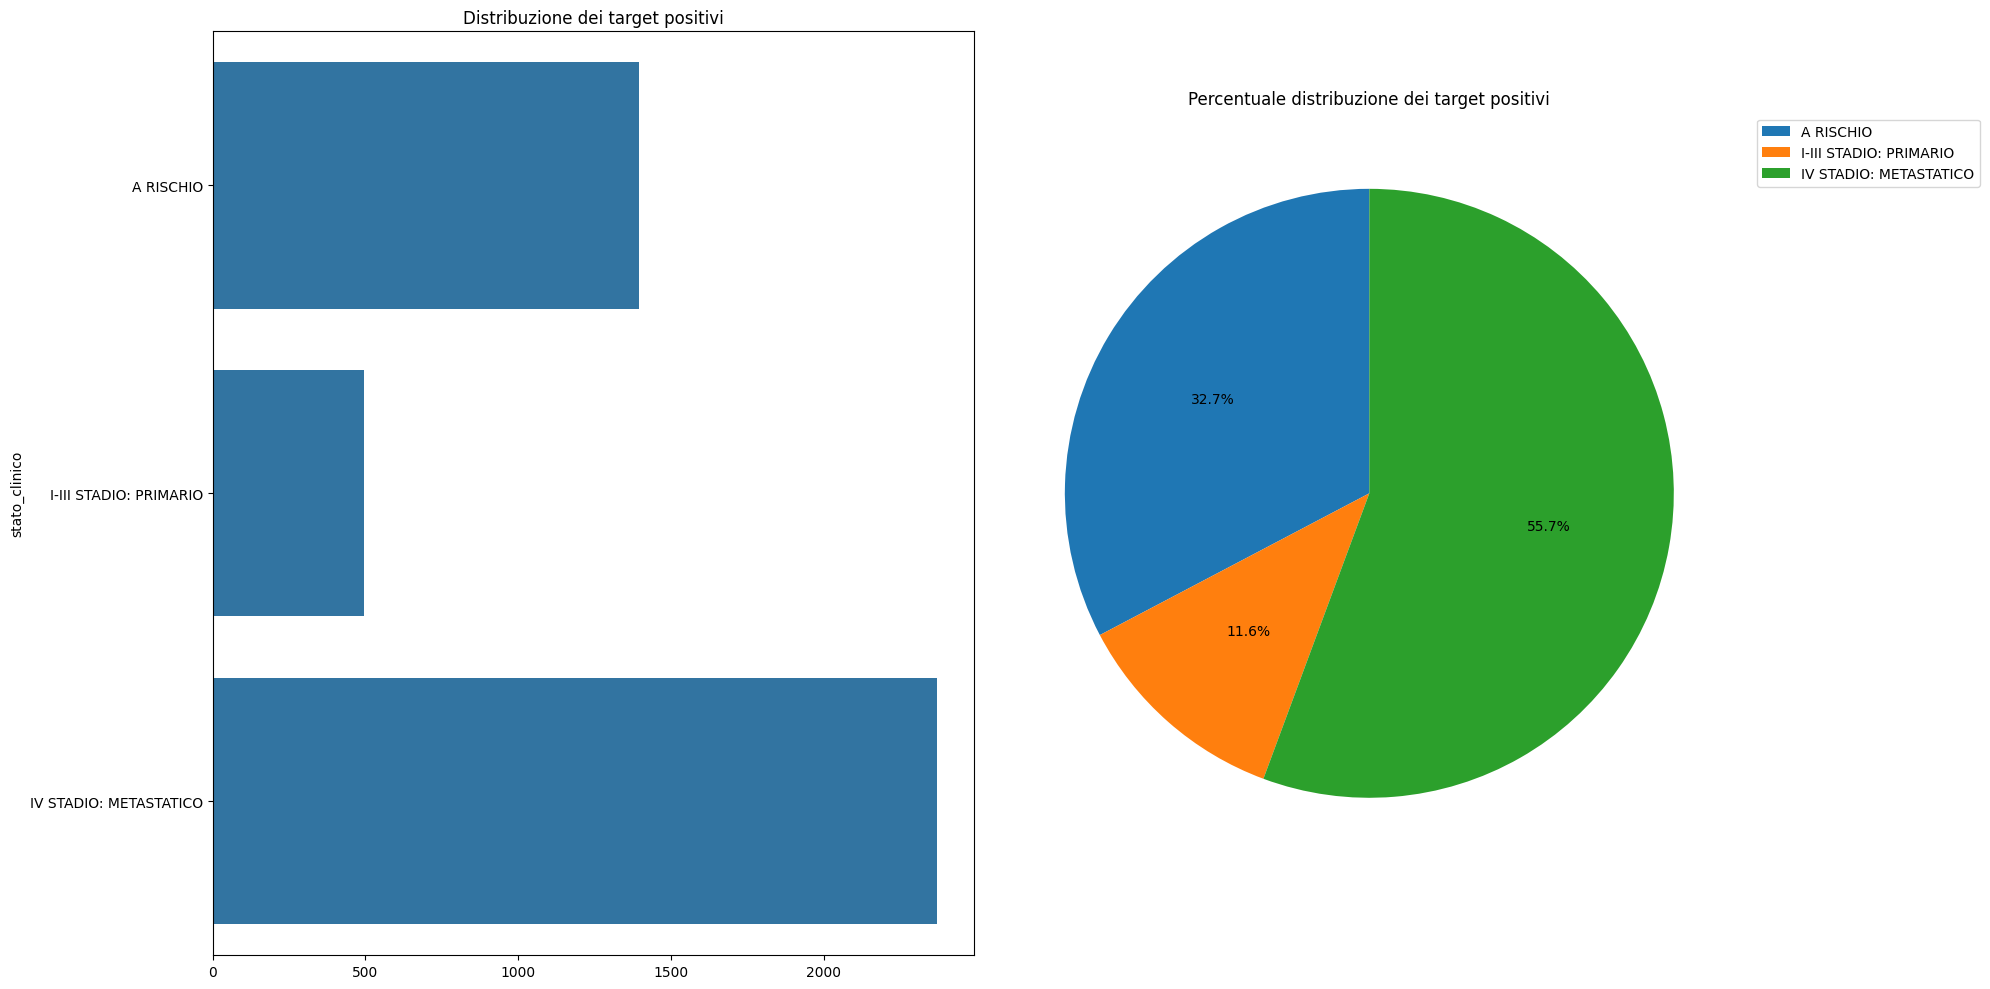

In [70]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
tipi_positivi = [
    'A RISCHIO', 
    'I-III STADIO: PRIMARIO', 
    'IV STADIO: METASTATICO'
]
positivi = dataset.query("stato_clinico != 'NEGATIVO'")
conta_positivi = positivi['stato_clinico'].value_counts().reindex(tipi_positivi)
sns.barplot(x=conta_positivi.values, y=conta_positivi.index, ax=axis[0])
axis[1].pie(conta_positivi.values, labels=None, autopct='%1.1f%%', startangle=90)
axis[0].set_title("Distribuzione dei target positivi")
axis[1].set_title("Percentuale distribuzione dei target positivi")
axis[1].legend(labels=tipi_positivi, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Come si può notare, il dataset dei positivi risulta leggermente più bilanciato. Perciò, si procede con il data augumentation del I-III stadio, poiché i casi sono veramente rari; e con l'Weighted Cross-Entropy Loss, perché non è presente molta differenza con quelli a rischio. 

In [71]:
dataset['numero_severita'] = dataset['numero_severita'].replace({3: 2, 4: 3})
mappa_nomi = {
    0: "NEGATIVO",
    1: "A RISCHIO",
    2: "PRIMARIO",
    3: "METASTATICO"
}
dataset['stato_clinico'] = dataset['numero_severita'].map(mappa_nomi)

In [72]:
mapping_gender = {'M': 0, 'F': 1}
dataset['gender'] = dataset['gender'].map(mapping_gender)
posizioni_uniche = dataset['ViewPosition'].unique()
mapping_view = {pos: ind for ind, pos in enumerate(posizioni_uniche)}
dataset['ViewPosition'] = dataset['ViewPosition'].map(mapping_view)
dataset['StudyDate'] = pd.to_numeric(dataset['StudyDate'], errors='coerce').fillna(0)
dataset['StudyTime'] = pd.to_numeric(dataset['StudyTime'], errors='coerce').fillna(0)
print("Dtypes dopo la conversione:")
print(dataset[['gender', 'ViewPosition', 'StudyDate', 'StudyTime']].dtypes)

Dtypes dopo la conversione:
gender            int64
ViewPosition      int64
StudyDate         int64
StudyTime       float64
dtype: object


In [73]:
dataset_pazienti = dataset[['subject_id', 'numero_severita']].drop_duplicates(subset=['subject_id'])
train_pazienti, temp_pazienti = train_test_split(
    dataset_pazienti,
    test_size = 0.20,
    stratify = dataset_pazienti['numero_severita'],
    random_state = 42
)
val_pazienti, test_pazienti = train_test_split(
    temp_pazienti,
    test_size = 0.50,
    stratify = temp_pazienti['numero_severita'],
    random_state = 42
)
train_set = dataset[dataset['subject_id'].isin(train_pazienti['subject_id'])].copy()
validation_set = dataset[dataset['subject_id'].isin(val_pazienti['subject_id'])].copy()
test_set = dataset[dataset['subject_id'].isin(test_pazienti['subject_id'])].copy()
train_set

,subject_id,gender,anchor_age,dicom_id,study_id,ViewPosition,StudyDate,StudyTime,path_immagine,testo_referto,numero_severita,stato_clinico
0,10000898,1,80,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,0,21880312,125501.842,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...,0,NEGATIVO
1,10000935,1,52,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,0,21860730,155005.000,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...,3,METASTATICO
2,10001401,1,89,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,1,21310610,102234.484,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,1,A RISCHIO
3,10001401,1,89,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,0,21310619,193047.156,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,1,A RISCHIO
4,10001401,1,89,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,0,21310802,114559.000,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,1,A RISCHIO
...,...,...,...,...,...,...,...,...,...,...,...,...
22761,19997911,1,79,826b4469-6017264c-2ddd12e8-2e3e5c4c-fe2817bd,50641994,0,21920311,100844.000,data/MIMIC_SUPER_RES_24K/826b4469-6017264c-2dd...,FINAL REPORT\...,0,NEGATIVO
22764,19998350,0,52,d14b91a7-2deb65ba-dea8e4b9-b7bbeb5e-f3ac734f,51819111,0,21280221,85427.984,data/MIMIC_SUPER_RES_24K/d14b91a7-2deb65ba-dea...,FINAL REPORT\...,0,NEGATIVO
22765,19999287,1,71,50373d1b-8df0d15f-5d0047f4-578bc509-4f2b48f0,51885769,1,21970726,25712.640,data/MIMIC_SUPER_RES_24K/50373d1b-8df0d15f-5d0...,FINAL REPORT\...,2,PRIMARIO
22766,19999287,1,71,46510b80-411ac511-fe6ffab2-d7dfdc76-dff1a762,52519175,1,21970807,90637.796,data/MIMIC_SUPER_RES_24K/46510b80-411ac511-fe6...,FINAL REPORT\...,2,PRIMARIO


## Data augmentation

In [74]:
base = T.Compose([
    T.Resize((224, 224)), # Risoluzione tipica per le CNN
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]) # Uso immagini in scala di grigi
])

augmentation = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=5), # massimo 5°
    T.RandomAffine(degrees=0, translate=(0.02, 0.02)), # piccole traslazioni
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

## Undersampling

Per eseguire l'undersampling, trovo i pazienti sani simili, con la logica degli N-grammi e la Cosine Similarity.

In [75]:
train_negativi = train_set[train_set['numero_severita'] == 0].reset_index(drop=True)
train_positivi = train_set[train_set['numero_severita'] != 0].reset_index(drop=True)
vectorizer = CountVectorizer(ngram_range=(1, 2), binary=True)
testo_negativi = train_negativi['testo_referto'].fillna('')
ngram_matrix = vectorizer.fit_transform(testo_negativi)
sim_matrix = cosine_similarity(ngram_matrix, dense_output=False)

soglia = 0.8
pazienti_buoni = []
scartati = np.zeros(sim_matrix.shape[0], dtype=bool)

for ind in range(sim_matrix.shape[0]):
    if scartati[ind]:
        continue
    pazienti_buoni.append(ind)
    record = sim_matrix.getrow(ind).toarray().flatten()
    cloni = np.where(record > soglia)[0]

    for clone in cloni:
        if clone != ind:
            scartati[clone] = True

target_negativi = 3000
filtrati = train_negativi.iloc[pazienti_buoni]
filtrati = filtrati.sample(n=target_negativi, random_state=42)
train_set = pd.concat([filtrati, train_positivi]).sample(frac=1, random_state=42).reset_index(drop=True)

In [76]:
# Verifichiamo la distribuzione finale nel set di addestramento
print("--- DISTRIBUZIONE FINALE TRAIN SET ---")
print(train_set['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE FINALE TRAIN SET ---
stato_clinico
NEGATIVO       3000
METASTATICO    1902
A RISCHIO      1108
PRIMARIO        389
Name: count, dtype: int64

Totale immagini per l'addestramento: 6399


## Weighted Cross-Entropy

In [77]:
def calcola_pesi_loss(dataframe, augmentation=True):
    conta_tipi_target = dataframe['numero_severita'].value_counts()
    num_negativo = conta_tipi_target.get(0, 1)
    num_rischio = conta_tipi_target.get(1, 1)
    num_primario = conta_tipi_target.get(2, 1)
    num_metastatico = conta_tipi_target.get(3, 1)

    if augmentation:
        pesi = [1.0, num_negativo/num_rischio, 1.0, num_negativo/num_metastatico]
    else:
        pesi = [1.0, num_negativo/num_rischio, num_negativo/num_primario, num_negativo/num_metastatico]
    print(pesi)
    return torch.tensor(pesi, dtype=torch.float32)

Con Augmentation

In [78]:
pesi_aug = calcola_pesi_loss(train_set, augmentation=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterio = nn.CrossEntropyLoss(weight=pesi_aug.to(device))
train_set_aug = RXToraceDataset(
    dataframe=train_set,
    cartella=ricerca,
    transform_base=base,
    transform_aug=augmentation 
)

[1.0, np.float64(2.707581227436823), 1.0, np.float64(1.5772870662460567)]


Senza Augmentation

In [79]:
pesi_no_aug = calcola_pesi_loss(train_set, augmentation=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterio = nn.CrossEntropyLoss(weight=pesi_aug.to(device))
train_set_aug = RXToraceDataset(
    dataframe=train_set,
    cartella=ricerca,
    transform_base=base,
    transform_aug=None 
)

[1.0, np.float64(2.707581227436823), np.float64(7.712082262210797), np.float64(1.5772870662460567)]


In [80]:
dataset

,subject_id,gender,anchor_age,dicom_id,study_id,ViewPosition,StudyDate,StudyTime,path_immagine,testo_referto,numero_severita,stato_clinico
0,10000898,1,80,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,50771383,0,21880312,125501.842,data/MIMIC_SUPER_RES_24K/2a280266-c8bae121-54d...,FINAL REPORT\...,0,NEGATIVO
1,10000935,1,52,f1adcae3-2921c0a8-5d9652f9-4191ecd7-f2a96f35,56522600,0,21860730,155005.000,data/MIMIC_SUPER_RES_24K/f1adcae3-2921c0a8-5d9...,FINAL REPORT\...,3,METASTATICO
2,10001401,1,89,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,50225296,1,21310610,102234.484,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,1,A RISCHIO
3,10001401,1,89,c74ce171-c7c53262-a7d57fa1-ee9a9bea-b5f75cb8,51065211,0,21310619,193047.156,data/MIMIC_SUPER_RES_24K/c74ce171-c7c53262-a7d...,FINAL REPORT\...,1,A RISCHIO
4,10001401,1,89,d9db838d-4612fd1e-e45b40a9-3ea30033-26efd8e4,55350604,0,21310802,114559.000,data/MIMIC_SUPER_RES_24K/d9db838d-4612fd1e-e45...,FINAL REPORT\...,1,A RISCHIO
...,...,...,...,...,...,...,...,...,...,...,...,...
22763,19998330,1,71,05405a03-c11efc6e-8a4366b6-d929640f-c356d564,59735820,1,21781021,170349.875,data/MIMIC_SUPER_RES_24K/05405a03-c11efc6e-8a4...,FINAL REPORT\...,0,NEGATIVO
22764,19998350,0,52,d14b91a7-2deb65ba-dea8e4b9-b7bbeb5e-f3ac734f,51819111,0,21280221,85427.984,data/MIMIC_SUPER_RES_24K/d14b91a7-2deb65ba-dea...,FINAL REPORT\...,0,NEGATIVO
22765,19999287,1,71,50373d1b-8df0d15f-5d0047f4-578bc509-4f2b48f0,51885769,1,21970726,25712.640,data/MIMIC_SUPER_RES_24K/50373d1b-8df0d15f-5d0...,FINAL REPORT\...,2,PRIMARIO
22766,19999287,1,71,46510b80-411ac511-fe6ffab2-d7dfdc76-dff1a762,52519175,1,21970807,90637.796,data/MIMIC_SUPER_RES_24K/46510b80-411ac511-fe6...,FINAL REPORT\...,2,PRIMARIO


# Parte 4: Addestramento e risultati

In [81]:
ricerca_train = os.path.join(os.getcwd())

In [82]:
# Training clinico
feat_cols = ['gender', 'anchor_age', 'ViewPosition', 'StudyDate', 'StudyTime']
clinical_model = train_modello_clinico(train_set, validation_set, feat_cols)


--- TRAINING MODELLO CLINICO ---
[0]	validation_0-mlogloss:1.38489
[100]	validation_0-mlogloss:1.30900


[200]	validation_0-mlogloss:1.28515
[300]	validation_0-mlogloss:1.27562
[400]	validation_0-mlogloss:1.26744
[499]	validation_0-mlogloss:1.26242


In [ ]:
from PIL import Image

# Disabilita il limite di sicurezza per le immagini mediche ad altissima risoluzione
Image.MAX_IMAGE_PIXELS = None

In [83]:
# Training modello visivo con augmentation
model_aug = train_modello_visivo(train_set, validation_set, ricerca_train, base, augmentation, 
                               pesi_aug, device, use_aug=True)


--- TRAINING MODELLO VISIVO (AUG) ---
Ripresa addestramento dall'epoca 4


Epoca 5/30:   0%|          | 0/800 [00:00<?, ?it/s]

[AUG] Epoca 5 - Loss: 1.1703 - F1: 0.5694
Nuovo miglior modello AUG salvato!


Epoca 6/30:   0%|          | 0/800 [00:00<?, ?it/s]

[AUG] Epoca 6 - Loss: 1.1452 - F1: 0.5393


...

[AUG] Epoca 28 - Loss: 0.1883 - F1: 0.5558


Epoca 29/30:   0%|          | 0/800 [00:00<?, ?it/s]

[AUG] Epoca 29 - Loss: 0.1716 - F1: 0.5388


Epoca 30/30:   0%|          | 0/800 [00:00<?, ?it/s]

[AUG] Epoca 30 - Loss: 0.1629 - F1: 0.5676


In [ ]:
# Training modello visivo senza augmentation
model_noaug = train_modello_visivo(train_set, validation_set, ricerca_train, base, augmentation, 
                                 pesi_no_aug, device, use_aug=False)


--- TRAINING MODELLO VISIVO (NOAUG) ---


Epoca 1/30:   0%|          | 0/800 [00:00<?, ?it/s]

[NOAUG] Epoca 1 - Loss: 1.3781 - F1: 0.5337
Nuovo miglior modello NOAUG salvato!


Epoca 2/30:   0%|          | 0/800 [00:00<?, ?it/s]

[NOAUG] Epoca 2 - Loss: 1.3671 - F1: 0.6090
Nuovo miglior modello NOAUG salvato!


...

[NOAUG] Epoca 28 - Loss: 0.2191 - F1: 0.5836


Epoca 29/30:   0%|          | 0/800 [00:00<?, ?it/s]

[NOAUG] Epoca 29 - Loss: 0.2098 - F1: 0.5685


Epoca 30/30:   0%|          | 0/800 [00:00<?, ?it/s]

[NOAUG] Epoca 30 - Loss: 0.1827 - F1: 0.5854


In [ ]:
dataset_test = RXToraceDataset(dataframe=test_set, cartella=ricerca_train, transform_base=base, transform_aug=None)

In [ ]:
def estrai_predizioni_test(v_model, c_model, test_df, dataset_test, mappa_nomi, device):
    """
    Esegue l'inferenza una sola volta su tutto il test set e salva i risultati grezzi.
    """
    v_model.eval()
    fusion_sys = DiagnosiIntegrata(v_model, c_model, device=str(device))
    results = []
    
    totale = len(test_df)
    print(f"Estrazione predizioni in corso su {totale} pazienti...")
    
    for idx in range(totale):
        if idx > 0 and idx % 50 == 0:
            print(f"Elaborati {idx}/{totale} pazienti...")

        row = test_df.iloc[[idx]]
        img_tensor, label_tensor, _ = dataset_test[idx]
        label_reale = label_tensor.item()
        nome_classe_reale = mappa_nomi[label_reale]
        
        # Diagnosi Integrata
        output_integrato = fusion_sys.diagnosi(img_tensor, row)
        predizione_finale = output_integrato['diagnosi']
        
        # Confidenze Pure
        with torch.no_grad():
            img_device = img_tensor.to(device).unsqueeze(0)
            logits, _ = v_model(img_device)
            prob_vision_dist = torch.softmax(logits, dim=1).cpu().numpy()[0]
            prob_vision = prob_vision_dist[label_reale]
        
        prob_clinical_dist = c_model.predict(row)
        prob_clinical = prob_clinical_dist[label_reale]
        
        results.append({
            'classe_reale': nome_classe_reale,
            'predizione_integrata': predizione_finale, # FONDAMENTALE PER LA MATRICE
            'conf_vision': prob_vision,
            'conf_clinical': prob_clinical,
            'corretta': predizione_finale == nome_classe_reale
        })

    print("Estrazione completata!")
    return pd.DataFrame(results)

In [ ]:
def plot_scatterplot_fusione(res_df):
    """
    Genera lo scatterplot delle confidenze Visione vs Clinica.
    """
    plt.figure(figsize=(12, 8))
    palette = {"NEGATIVO": "#2ecc71", "A RISCHIO": "#f1c40f", "PRIMARIO": "#e67e22", "METASTATICO": "#e74c3c"}
    
    sns.scatterplot(
        data=res_df, 
        x='conf_vision', 
        y='conf_clinical', 
        hue='classe_reale', 
        style='corretta',
        markers={True: "o", False: "X"},
        palette=palette,
        s=100, 
        alpha=0.7
    )
    
    plt.axline((0, 0), slope=1, color='black', linestyle='--', alpha=0.4, label='Equilibrio Visione/Clinica')
    plt.title("Analisi della Fusione: Confidenza Visione vs Clinica", fontsize=14)
    plt.xlabel("Confidenza Pura Ramo Visivo", fontsize=12)
    plt.ylabel("Confidenza Pura Ramo Clinico", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Legenda")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig('analisi_fusione_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_matrice_confusione(res_df, lista_classi):
    """
    Genera la heatmap della matrice di confusione del sistema integrato.
    """
    # Estraiamo le colonne che ci interessano dal DataFrame
    y_reali = res_df['classe_reale']
    y_predetti = res_df['predizione_integrata']
    
    # Calcolo matematico
    cm = confusion_matrix(y_reali, y_predetti, labels=lista_classi)
    
    # Disegno grafico
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=lista_classi, yticklabels=lista_classi,
                cbar_kws={'label': 'Numero di Pazienti'})
    
    plt.title('Matrice di Confusione - Diagnosi Integrata (Visiva + Clinica)', fontsize=14, pad=20)
    plt.xlabel('Diagnosi PREVISTA dal Sistema', fontsize=12, labelpad=10)
    plt.ylabel('Diagnosi REALE (Ground Truth)', fontsize=12, labelpad=10)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('matrice_confusione_integrata.png', dpi=300)
    plt.show()

In [ ]:
# 1. Estrai i dati (Ci metterà qualche minuto, usa la GPU)
df_risultati = estrai_predizioni_test(model_aug, clinical_model, test_set, dataset_test, mappa_nomi, device)
classi_ordinate = ["NEGATIVO", "A RISCHIO", "PRIMARIO", "METASTATICO"]

Estrazione predizioni in corso su 2259 pazienti...


Elaborati 50/2259 pazienti...
Elaborati 100/2259 pazienti...
Elaborati 150/2259 pazienti...
Elaborati 200/2259 pazienti...
Elaborati 250/2259 pazienti...
Elaborati 300/2259 pazienti...
Elaborati 350/2259 pazienti...
Elaborati 400/2259 pazienti...
Elaborati 450/2259 pazienti...
Elaborati 500/2259 pazienti...
Elaborati 550/2259 pazienti...
Elaborati 600/2259 pazienti...
Elaborati 650/2259 pazienti...
Elaborati 700/2259 pazienti...
Elaborati 750/2259 pazienti...
Elaborati 800/2259 pazienti...
Elaborati 850/2259 pazienti...
Elaborati 900/2259 pazienti...
Elaborati 950/2259 pazienti...
Elaborati 1000/2259 pazienti...
Elaborati 1050/2259 pazienti...
Elaborati 1100/2259 pazienti...
Elaborati 1150/2259 pazienti...
Elaborati 1200/2259 pazienti...
Elaborati 1250/2259 pazienti...
Elaborati 1300/2259 pazienti...
Elaborati 1350/2259 pazienti...
Elaborati 1400/2259 pazienti...
Elaborati 1450/2259 pazienti...
Elaborati 1500/2259 pazienti...
Elaborati 1550/2259 pazienti...
Elaborati 1600/2259 pazienti

In [ ]:
df_noaug = estrai_predizioni_test(model_noaug, clinical_model, test_set, dataset_test, mappa_nomi, device)

Estrazione predizioni in corso su 2259 pazienti...
Elaborati 50/2259 pazienti...
Elaborati 100/2259 pazienti...
Elaborati 150/2259 pazienti...
Elaborati 200/2259 pazienti...
Elaborati 250/2259 pazienti...
Elaborati 300/2259 pazienti...
Elaborati 350/2259 pazienti...
Elaborati 400/2259 pazienti...
Elaborati 450/2259 pazienti...
Elaborati 500/2259 pazienti...
Elaborati 550/2259 pazienti...
Elaborati 600/2259 pazienti...
Elaborati 650/2259 pazienti...
Elaborati 700/2259 pazienti...
Elaborati 750/2259 pazienti...
Elaborati 800/2259 pazienti...
Elaborati 850/2259 pazienti...
Elaborati 900/2259 pazienti...
Elaborati 950/2259 pazienti...
Elaborati 1000/2259 pazienti...
Elaborati 1050/2259 pazienti...
Elaborati 1100/2259 pazienti...
Elaborati 1150/2259 pazienti...
Elaborati 1200/2259 pazienti...
Elaborati 1250/2259 pazienti...
Elaborati 1300/2259 pazienti...
Elaborati 1350/2259 pazienti...
Elaborati 1400/2259 pazienti...
Elaborati 1450/2259 pazienti...
Elaborati 1500/2259 pazienti...
Elaborati

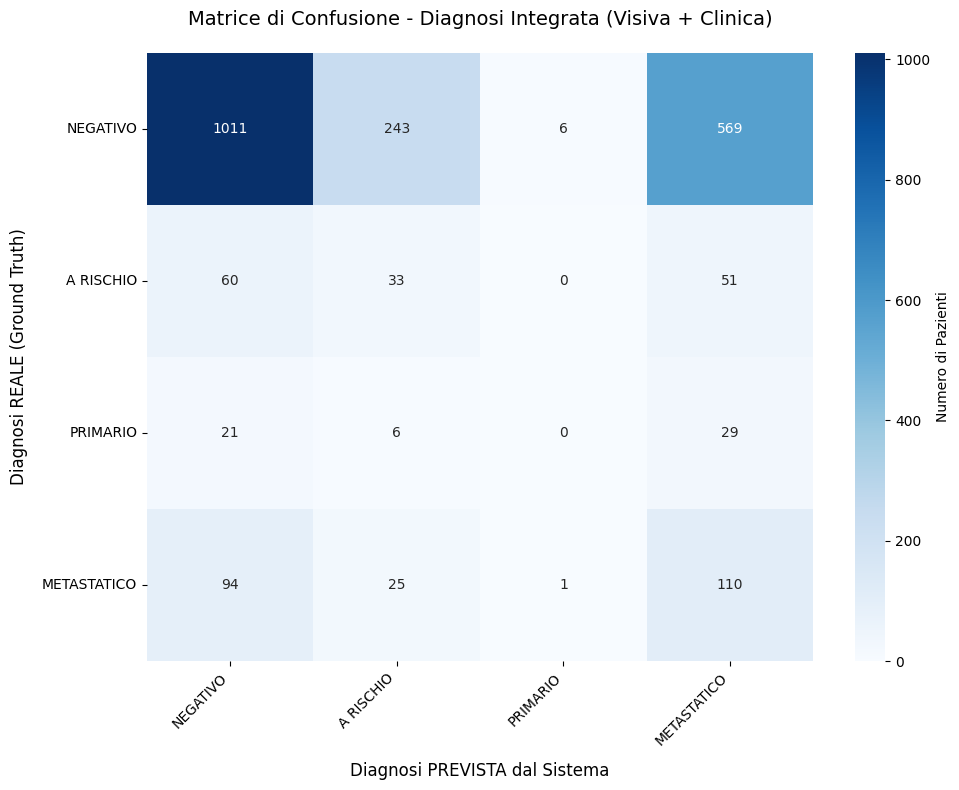

In [ ]:
plot_matrice_confusione(df_risultati, classi_ordinate)

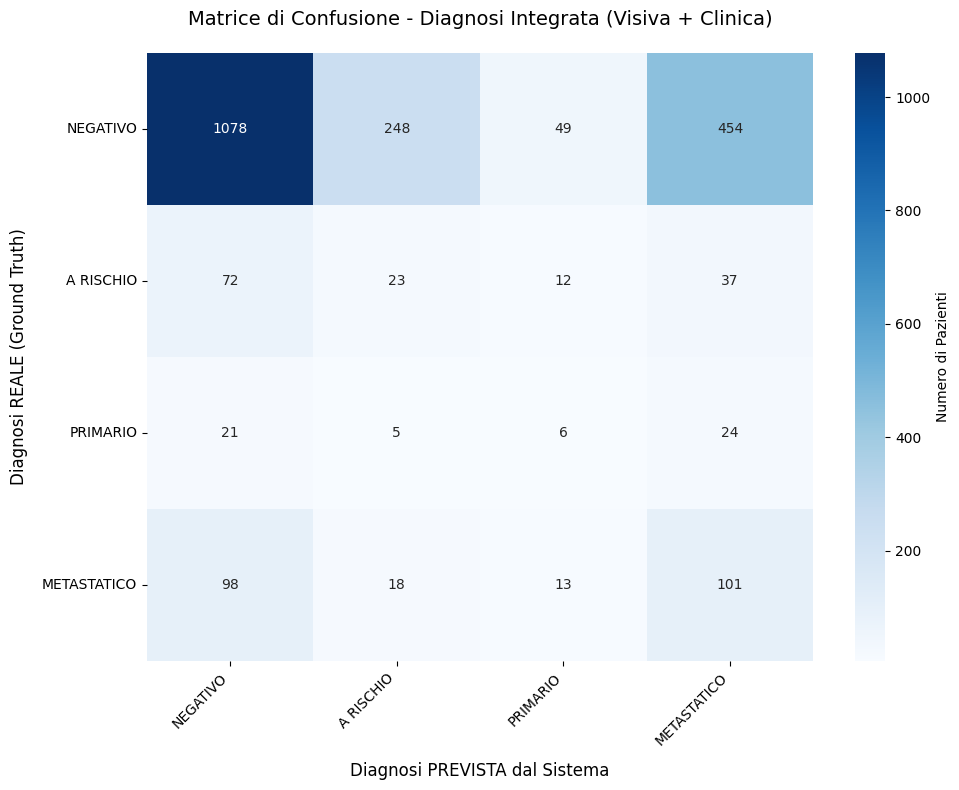

In [ ]:
plot_matrice_confusione(df_noaug, classi_ordinate)

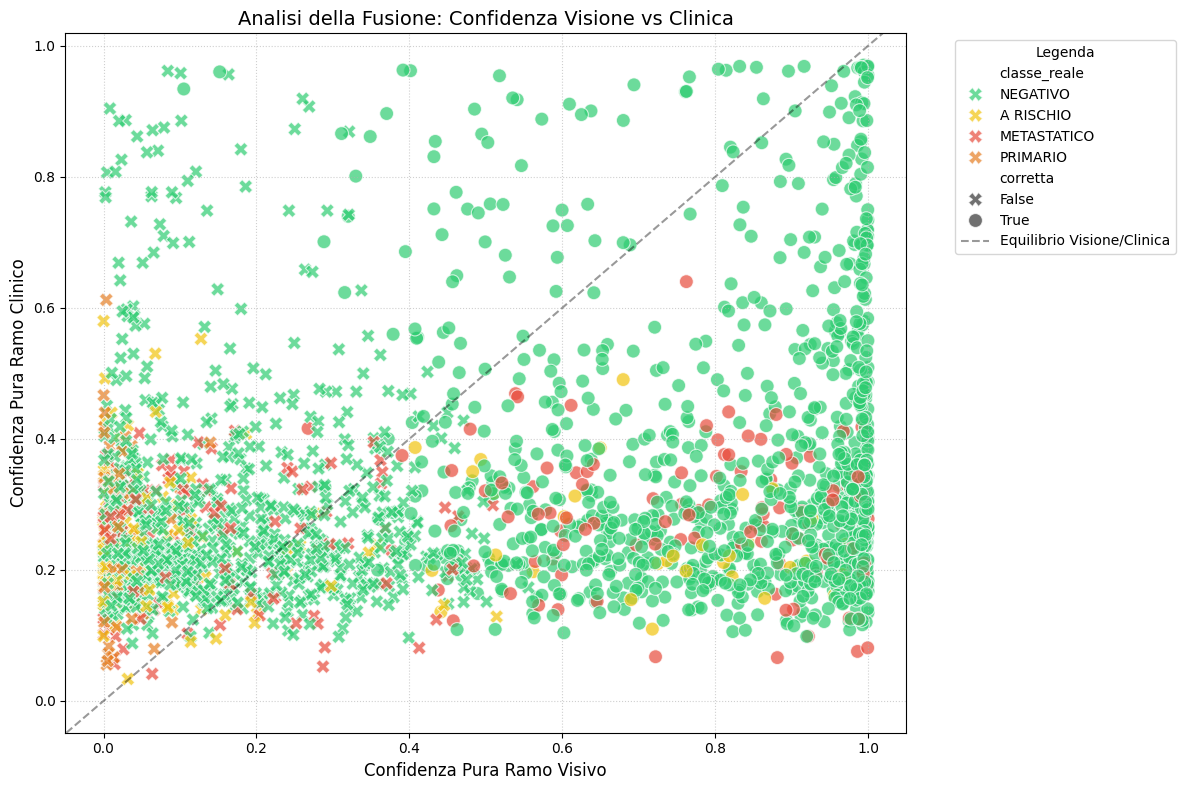

In [ ]:
plot_scatterplot_fusione(df_risultati)

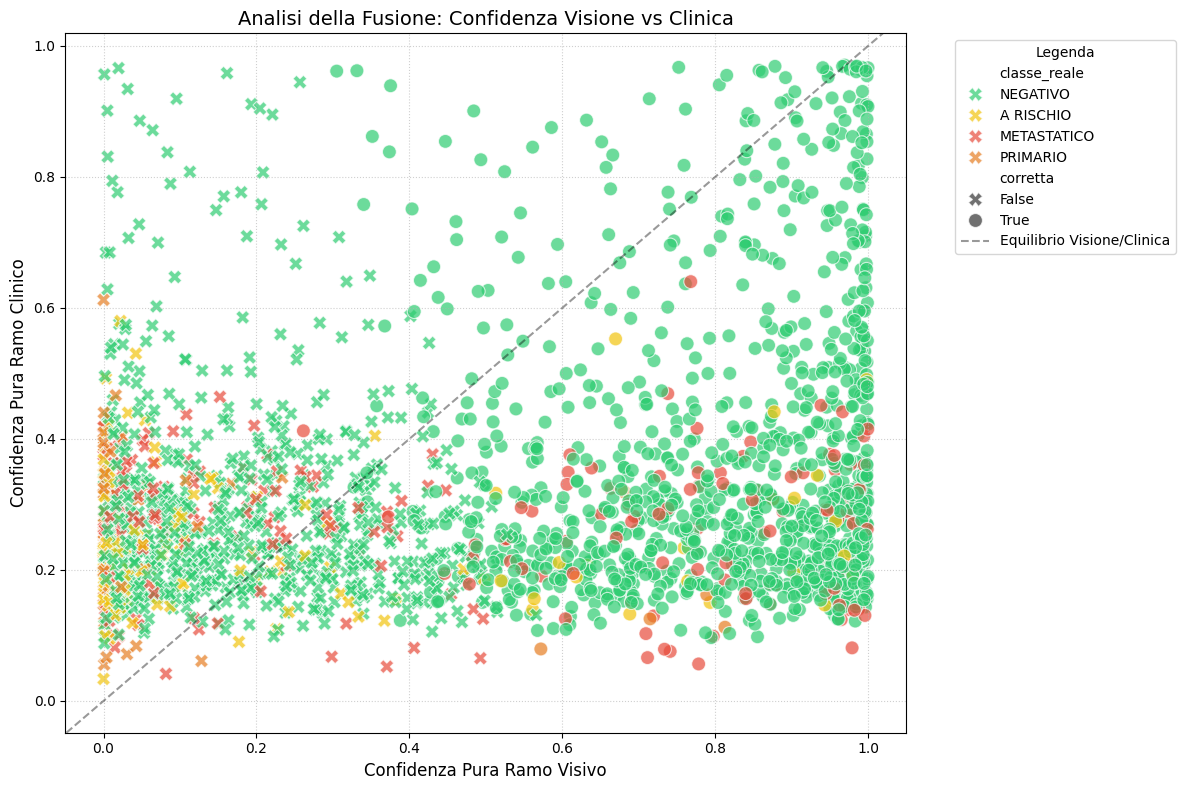

In [ ]:
plot_scatterplot_fusione(df_noaug)